# **FEATURE DIAGRAMS**

In [80]:
from IPython.display import Image
from graphviz import Digraph

COLORS = {
    'root':   '#3D4756',
    'mvp':    '#1D9E75',
    'phase2': '#378ADD',
    'future': '#EF9F27',
}

GRAPH_ATTRS = dict(
    bgcolor='white',
    fontname='Arial',
    pad='0.6',
    splines='curved',
    nodesep='0.8',
    ranksep='1.0',
)

EDGE_ATTRS = dict(
    color='#CCCCCC',
    arrowsize='0.7',
    penwidth='1.5',
)

NODE_ATTRS = dict(
    shape='circle',
    style='filled',
    fontname='Arial',
    fontsize='12',
    width='1.4',
    height='1.4',
    fixedsize='true',
    penwidth='0',
)

def node(graph, node_id, label, phase, textcolor='white'):
    graph.node(node_id, label,
        fillcolor=COLORS[phase],
        fontcolor=textcolor,
        **NODE_ATTRS,
    )

def build_graph(name, center_label, center_phase, children, filename):
    dot = Digraph(comment=name)
    dot.attr(**GRAPH_ATTRS)
    dot.attr('edge', **EDGE_ATTRS)

    center_id = name.lower().replace(' ', '_')
    node(dot, center_id, center_label, center_phase)

    for child in children:
        node(dot, child['id'], child['label'], child['phase'])
        dot.edge(center_id, child['id'])

    dot.render(filename, format='png', cleanup=True)
    return Image(f'{filename}.png')

# **AUTHENTICATION**

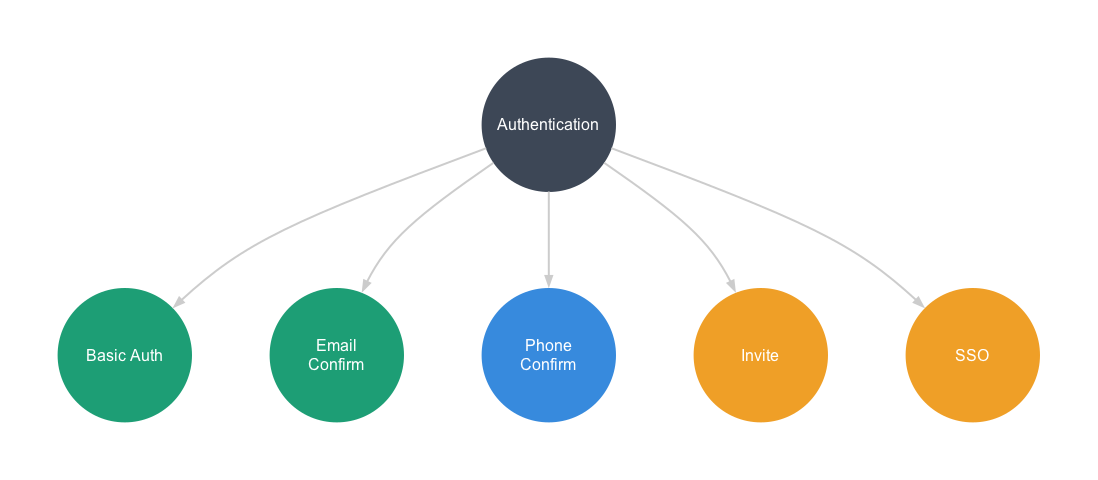

In [81]:
build_graph(
    name='Authentication',
    center_label='Authentication',
    center_phase='root',
    children=[
        {'id': 'basic', 'label': 'Basic Auth', 'phase': 'mvp'},
        {'id': 'email', 'label': 'Email\nConfirm', 'phase': 'mvp'},
        {'id': 'phone', 'label': 'Phone\nConfirm', 'phase': 'phase2'},
        {'id': 'invite', 'label': 'Invite', 'phase': 'future'},
        {'id': 'sso', 'label': 'SSO', 'phase': 'future'},
    ],
    filename='feature_map_auth_for_slot'
)

# **EXPLORE**

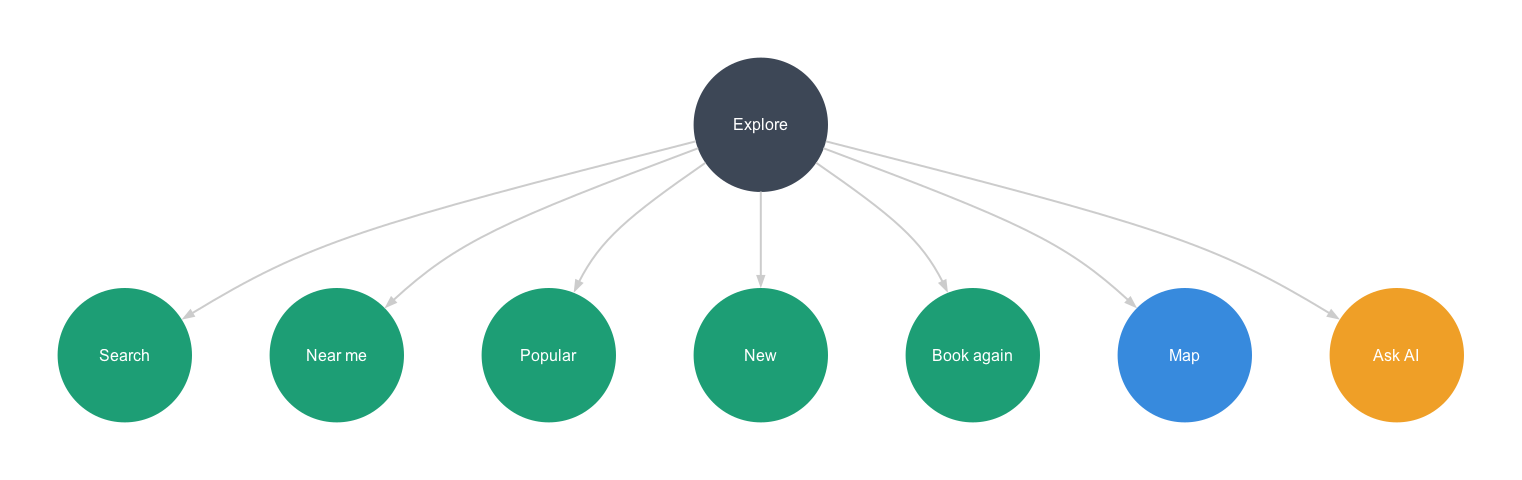

In [82]:
build_graph(
    name='Explore',
    center_label='Explore',
    center_phase='root',
    children=[
        {'id': 'search', 'label': 'Search', 'phase': 'mvp'},
        {'id': 'near-me', 'label': 'Near me', 'phase': 'mvp'},
        {'id': 'popular', 'label': 'Popular', 'phase': 'mvp'},
        {'id': 'new', 'label': 'New', 'phase': 'mvp'},
        {'id': 'book-again', 'label': 'Book again', 'phase': 'mvp'},
        {'id': 'map', 'label': 'Map', 'phase': 'phase2'},
        {'id': 'ask', 'label': 'Ask AI', 'phase': 'future'},
    ],
    filename='feature_map_explore_for_slot'
)

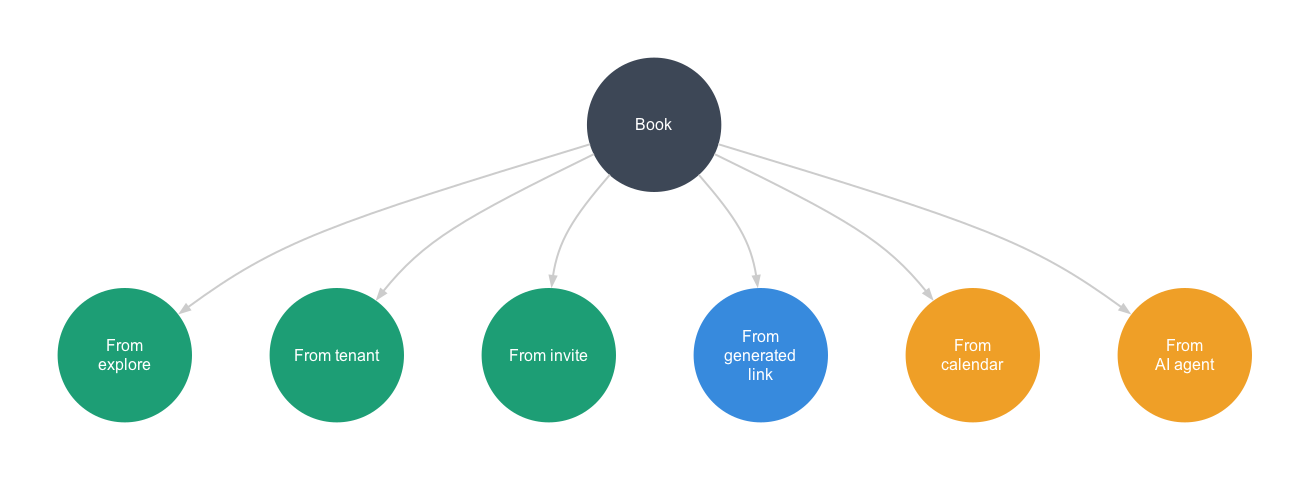

In [83]:
build_graph(
    name='Book',
    center_label='Book',
    center_phase='root',
    children=[
        {'id': 'from-explore', 'label': 'From\nexplore', 'phase': 'mvp'},
        {'id': 'from-tenant', 'label': 'From tenant', 'phase': 'mvp'},
        {'id': 'from-invite', 'label': 'From invite', 'phase': 'mvp'},
        {'id': 'from-generated-link', 'label': 'From\ngenerated\nlink', 'phase': 'phase2'},
        {'id': 'from-calendar', 'label': 'From\ncalendar', 'phase': 'future'},
        {'id': 'from-ai-agent', 'label': 'From\nAI agent', 'phase': 'future'},
    ],
    filename='feature_map_book_for_slot'
)